In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/diabetes.csv')
df = df[df['Glucose'] > 0]
df['Diabetes'] = df['Outcome'].map({0: 'No Diabetes', 1: 'Diabetes'})

print(df.shape)
print(df['Diabetes'].value_counts())

(763, 10)
Diabetes
No Diabetes    497
Diabetes       266
Name: count, dtype: int64


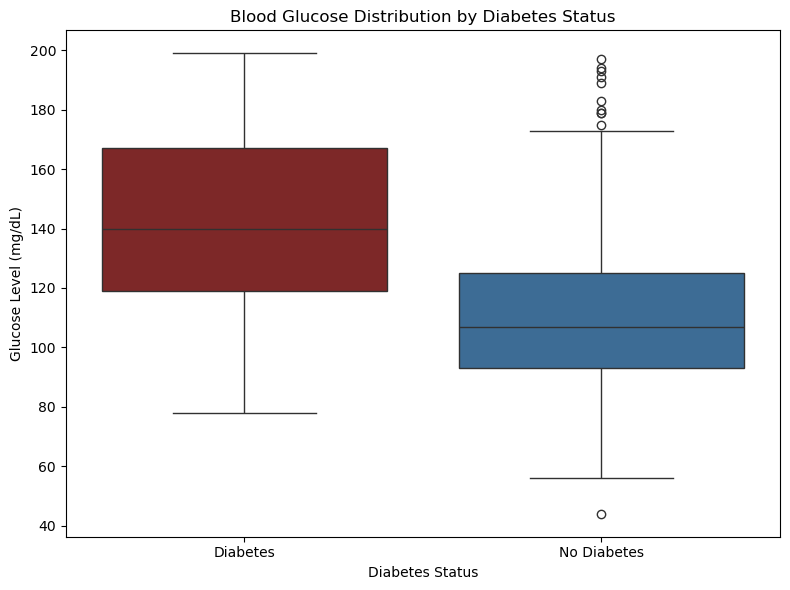

In [2]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x='Diabetes',
    y='Glucose',
    hue='Diabetes',
    palette={'No Diabetes': '#2E6DA4', 'Diabetes': '#8B1A1A'},
    legend=False
)
plt.title('Blood Glucose Distribution by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('Glucose Level (mg/dL)')
plt.tight_layout()
plt.savefig('../data/boxplot_glucose.png', dpi=150)
plt.show()

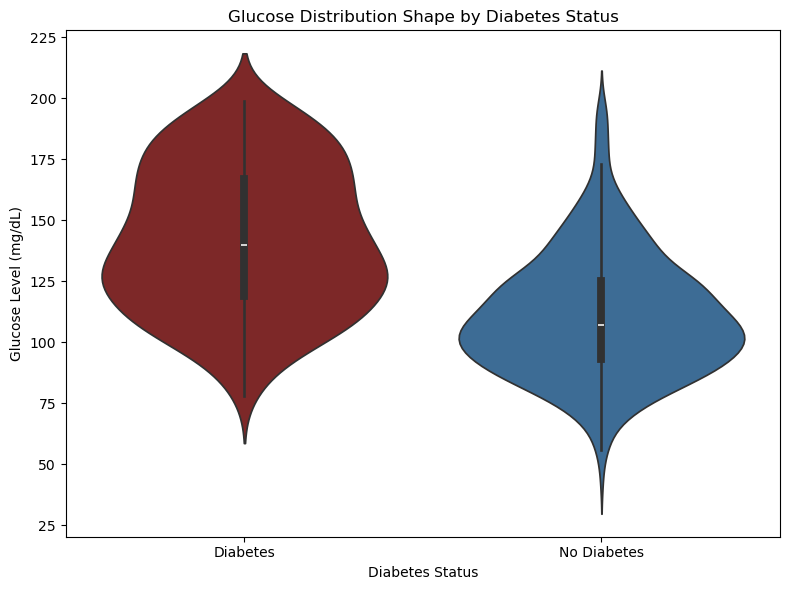

In [3]:
plt.figure(figsize=(8, 6))
sns.violinplot(
    data=df,
    x='Diabetes',
    y='Glucose',
    hue='Diabetes',
    palette={'No Diabetes': '#2E6DA4', 'Diabetes': '#8B1A1A'},
    inner='box',
    legend=False
)
plt.title('Glucose Distribution Shape by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('Glucose Level (mg/dL)')
plt.tight_layout()
plt.savefig('../data/violin_glucose.png', dpi=150)
plt.show()

## Violin Plot Interpretation

**Comparing the violin plot to the box plot — the violin plot adds information about:** The violin plot adds information about the actual shape of each group's distribution, not just the summary statistics. The box plot told me where the median and quartiles sat, but the violin shows me whether the data is symmetric, where it is most densely concentrated, and where extreme values tail off.

**Looking at the shape of the diabetic group's violin:** the distribution appears approximately symmetric, with the bulk of patients clustering between roughly 100 and 175 mg/dL and a median around 140 mg/dL, with tails extending relatively evenly in both directions.

**One thing the violin plot shows that the box plot from the previous chart could not show:** The non-diabetic group's violin, by contrast, is more clearly positively skewed — most patients cluster tightly around 100–120 mg/dL, but a tail stretches upward toward higher glucose values, while the lower end tapers to a sharp point quickly.

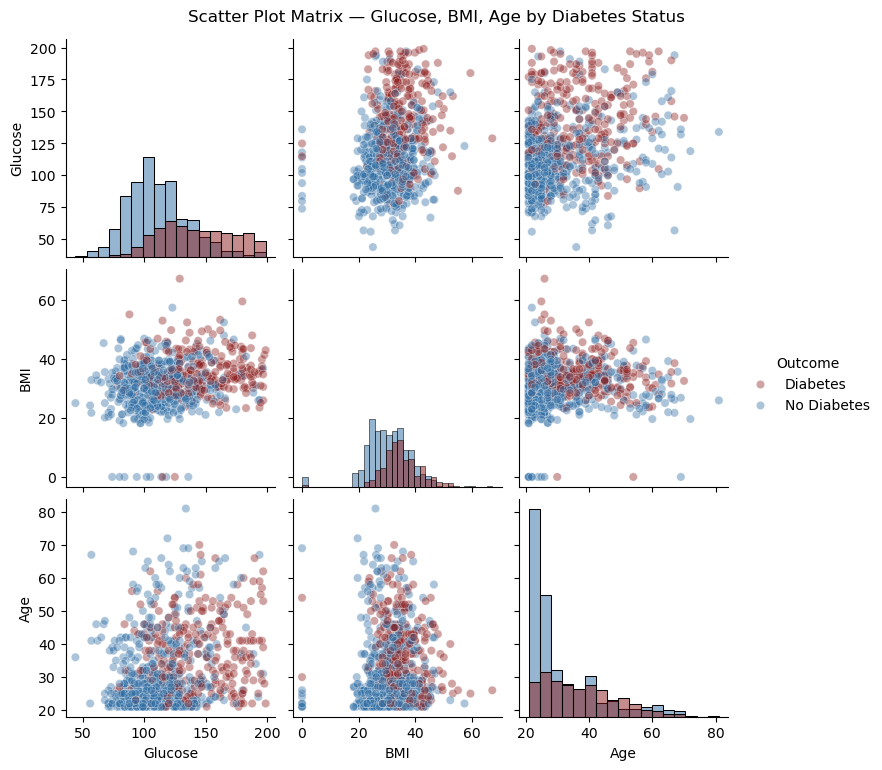

In [4]:
cols_of_interest = ['Glucose', 'BMI', 'Age', 'Outcome']
df_subset = df[cols_of_interest].copy()
df_subset['Outcome'] = df_subset['Outcome'].map({0: 'No Diabetes', 1: 'Diabetes'})

sns.pairplot(
    df_subset,
    hue='Outcome',
    palette={'No Diabetes': '#2E6DA4', 'Diabetes': '#8B1A1A'},
    diag_kind='hist',
    plot_kws={'alpha': 0.4}
)
plt.suptitle('Scatter Plot Matrix — Glucose, BMI, Age by Diabetes Status', 
             y=1.02)
plt.savefig('../data/pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Scatter Plot Matrix Interpretation

**The combination of variables that best visually separates diabetic from non-diabetic patients is:**
Glucose vs BMI and Glucose vs Age — in both panels, red (diabetic) dots are noticeably more concentrated at higher glucose values, while blue (non-diabetic) dots cluster at lower glucose values. However, even in these panels the separation is not clean — there is substantial overlap, confirming that no single pair of variables perfectly separates the two groups.

**The combination that least separates the two groups:** BMI vs Age — in this panel, red and blue dots are almost completely mixed together across all combinations of BMI and age, with no visible clustering of either group in any particular region. This is consistent with the heatmap from Day 3, where BMI and Age both showed relatively weak correlations with Outcome (0.29 and 0.24 respectively).

This connects to the correlation heatmap from Day 3 because the pairs that showed higher correlation with Outcome in the heatmap — particularly Glucose — also show the clearest visual separation here in the scatter matrix. The pairs with lower correlations (BMI vs Age, r = 0.03) show the least separation, exactly as the heatmap predicted. The scatter matrix is essentially a visual version of what the heatmap expressed numerically.

## Day 5 of July Complete

**The chart type I found most informative today and why:** I found the violin plot most informative because it was clearer in showing the distribution than the box plot.

**One clinical question I could answer using today's charts that I could not answer with just the correlation heatmap from Day 3:** "Are there diabetic patients who have normal glucose levels?" — Looking at the violin plot, I can see the diabetic group's distribution extends down toward lower glucose values, meaning yes, some diabetic patients in this dataset have glucose readings overlapping with the non-diabetic range. The heatmap's r = 0.49 told me there was a moderate correlation, but it could not show me this overlap visually or let me estimate how many patients sit in that ambiguous middle zone.

Confidence level today (honest, 1–10): 5.5